In [1]:
%pip install seaborn
%pip install jinja2
%pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pyodide.http import pyfetch

<ipython-input-2-939decdbb822>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
pd.set_option("display.max_columns", None)

<h1>Exploratory Data Analysis</h1>
<h2>Data Importation: Laptop Prices</h2>


In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
filename = "laptop_prices_dataset.csv"

In [5]:
async def download(url, filename): 
    try:
        response = await pyfetch(url)
        if response.status == 200:
            print(f"Connection to URL successful: status = {response.status}")
            with open (filename, "wb") as f:
                f.write(await response.bytes())
                print(f"{filename} successfully written")
    except Exception as e:
        print(f"Error dowloading data: {e}")

In [6]:
await download(url, filename)

Connection to URL successful: status = 200
laptop_prices_dataset.csv successfully written


<h2>Data Exploration</h2>

In [7]:
df = pd.read_csv(filename)
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


<h3>Information</h3>

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      238 non-null    int64  
 1   Unnamed: 0        238 non-null    int64  
 2   Manufacturer      238 non-null    object 
 3   Category          238 non-null    int64  
 4   GPU               238 non-null    int64  
 5   OS                238 non-null    int64  
 6   CPU_core          238 non-null    int64  
 7   Screen_Size_inch  238 non-null    float64
 8   CPU_frequency     238 non-null    float64
 9   RAM_GB            238 non-null    int64  
 10  Storage_GB_SSD    238 non-null    int64  
 11  Weight_pounds     238 non-null    float64
 12  Price             238 non-null    int64  
 13  Price-binned      238 non-null    object 
 14  Screen-Full_HD    238 non-null    int64  
 15  Screen-IPS_panel  238 non-null    int64  
dtypes: float64(3), int64(11), object(2)
memory u

In [9]:
df.describe(include = "all")

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238.000000,238.000000,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000,238.000000
unique,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
mean,118.500000,118.500000,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,0.676471,0.323529
std,68.848868,68.848868,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,0.468809,0.468809
min,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,0.000000,0.000000
25%,59.250000,59.250000,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,0.000000,0.000000
50%,118.500000,118.500000,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,1.000000,0.000000
75%,177.750000,177.750000,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,1.000000,1.000000


In [10]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
Manufacturer        0
Category            0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_pounds       0
Price               0
Price-binned        0
Screen-Full_HD      0
Screen-IPS_panel    0
dtype: int64

In [11]:
for col in df.columns:
    print(df[col].value_counts())

Unnamed: 0.1
0      1
163    1
151    1
152    1
153    1
      ..
83     1
84     1
85     1
86     1
237    1
Name: count, Length: 238, dtype: int64
Unnamed: 0
0      1
163    1
151    1
152    1
153    1
      ..
83     1
84     1
85     1
86     1
237    1
Name: count, Length: 238, dtype: int64
Manufacturer
Dell       71
Lenovo     52
HP         49
Acer       19
Asus       18
Toshiba    17
Samsung     5
MSI         4
Huawei      1
Razer       1
Xiaomi      1
Name: count, dtype: int64
Category
3    154
4     60
1     14
5      9
2      1
Name: count, dtype: int64
GPU
2    136
3     69
1     33
Name: count, dtype: int64
OS
1    224
2     14
Name: count, dtype: int64
CPU_core
5    123
7     95
3     20
Name: count, dtype: int64
Screen_Size_inch
15.6    93
14.0    64
15.0    23
13.3    20
13.0    18
17.3     7
17.0     5
12.5     4
12.0     4
Name: count, dtype: int64
CPU_frequency
0.862069    71
0.931034    43
0.551724    30
0.965517    25
0.620690    23
0.896552    11
0.793103    11


<h2>Regression:</h2>
<h3>Plots</h3>

In [12]:
ivariables = ["CPU_frequency", "Screen_Size_inch", "Weight_pounds"]
dv = "Price"

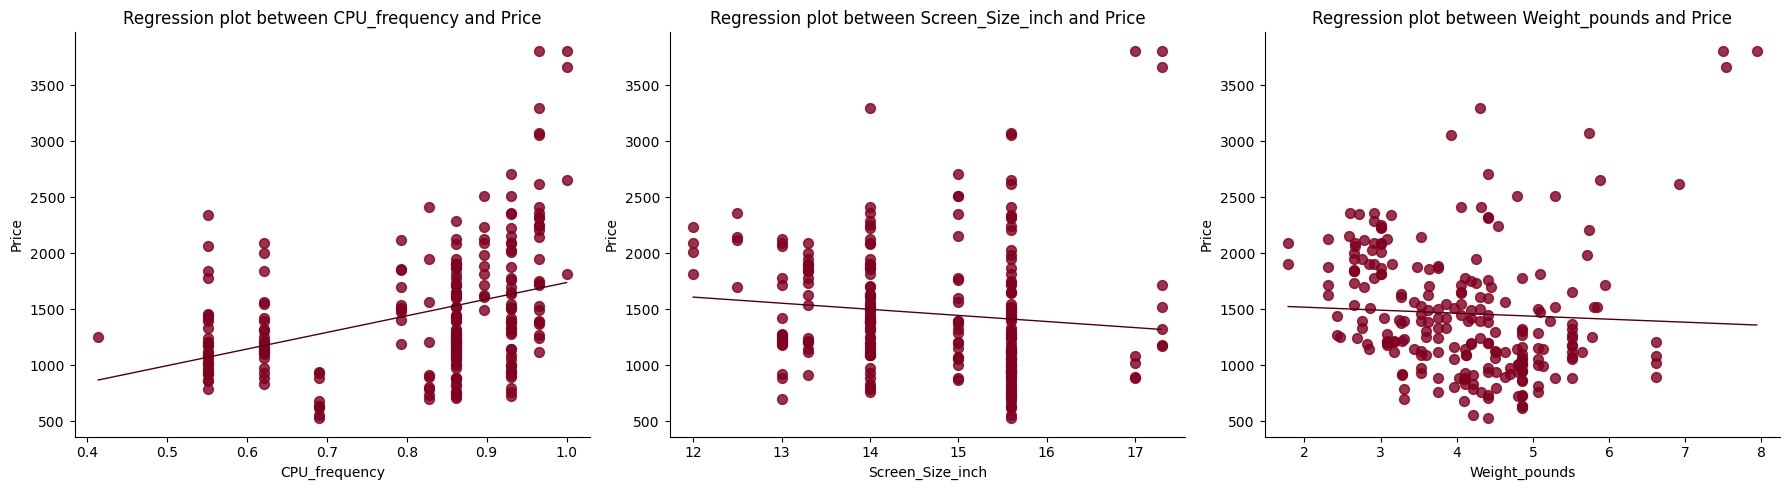

In [13]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, iv in zip(axes, ivariables):
    #plt.figure(figsize=(6,4))
    sns.regplot(x =iv, y = dv, data = df, ci = None, scatter_kws = {"color":"#800020", "s":50}, line_kws = {"color":"#4B0010", "linewidth": 1}, ax=ax)
    ax.set_xlabel(iv)
    ax.set_ylabel(dv)
    ax.set_title(f"Regression plot between {iv} and {dv}")
    sns.despine(ax=ax)
    plt.tight_layout()
plt.show()

<h3>Regression results:</h3>

In [14]:
from IPython.display import display, HTML
results = []
for iv in ivariables:
    pearson_coef, p_value = stats.pearsonr(df[iv], df[dv])
    sig = "sig" if p_value < .05 else "ns."
    results.append({
        "Associations": f"{iv} Vs. {dv}",
        "r" : f"{pearson_coef:.2f}",
        "p-value": f"{p_value:.3f} {sig}"
    })
df_result = pd.DataFrame(results)
display(HTML(df_result.to_html(index = False)))

Associations,r,p-value
CPU_frequency Vs. Price,0.37,0.000 sig
Screen_Size_inch Vs. Price,-0.11,0.089 ns.
Weight_pounds Vs. Price,-0.05,0.440 ns.


<h3>Box plots for categorical values</h3>

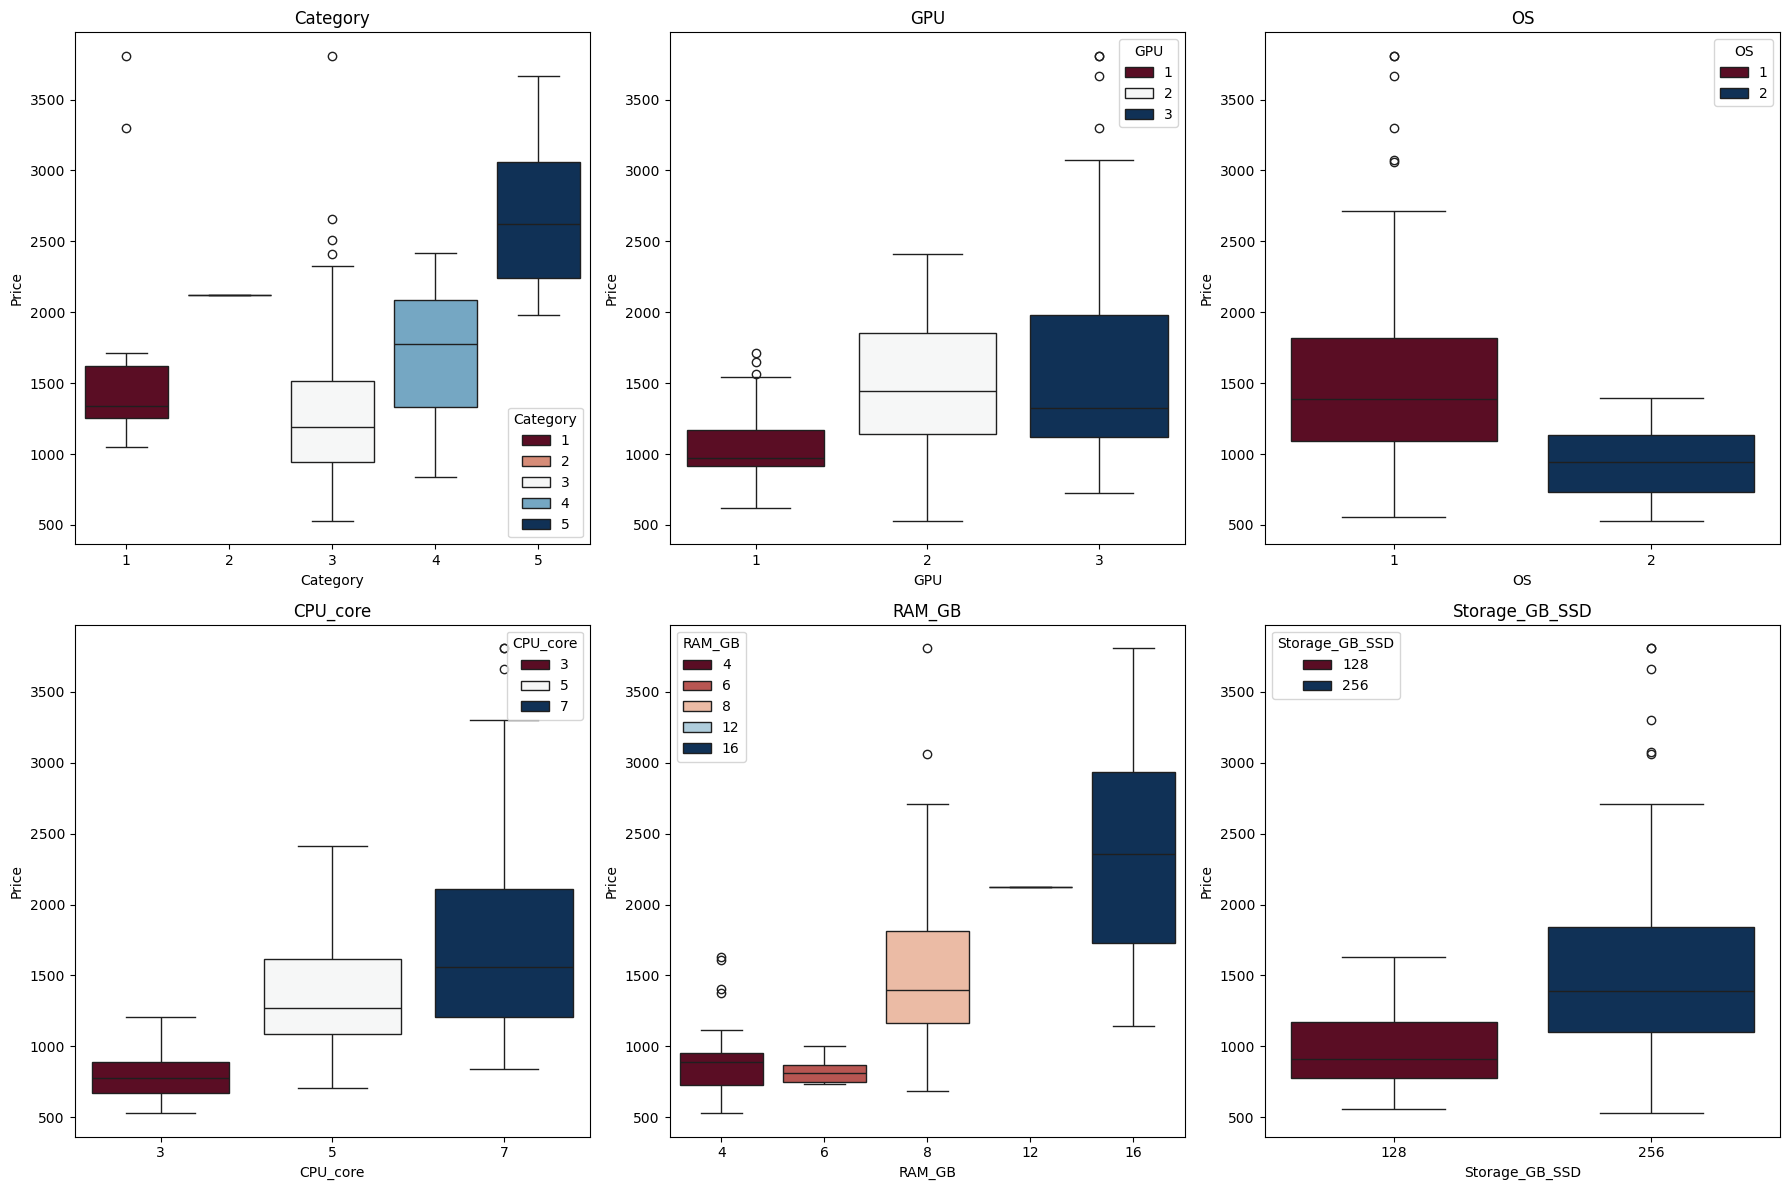

In [15]:
categories = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]
fig, axes = plt.subplots(2, 3, figsize=(18,12))

for ax, cat in zip(axes.flatten(), categories):
    sns.boxplot(x=cat, y=dv, data = df, ax = ax, hue = cat, palette = "RdBu")
    ax.set_title(cat)

plt.tight_layout()
plt.show()    

<h3>Pivot tables: GPU, CPU_core, and Price</h3>

In [16]:
table_GPU_CPU_core = df.groupby(["GPU", "CPU_core"], as_index = False).agg({"Price":"mean"}).round(2)
table_GPU_CPU_core

,GPU,CPU_core,Price
0,1,3,769.25
1,1,5,998.50
2,1,7,1167.94
3,2,3,785.08
4,2,5,1462.20
5,2,7,1744.62
6,3,3,784.00
7,3,5,1220.68
8,3,7,1945.10


In [17]:
pivot_GPU_CPU_core = table_GPU_CPU_core.pivot(index = "GPU", columns = "CPU_core")
pivot_GPU_CPU_core

Price                  
CPU_core       3        5        7
GPU                               
1         769.25   998.50  1167.94
2         785.08  1462.20  1744.62
3         784.00  1220.68  1945.10

<h4>Heat map: </h4>

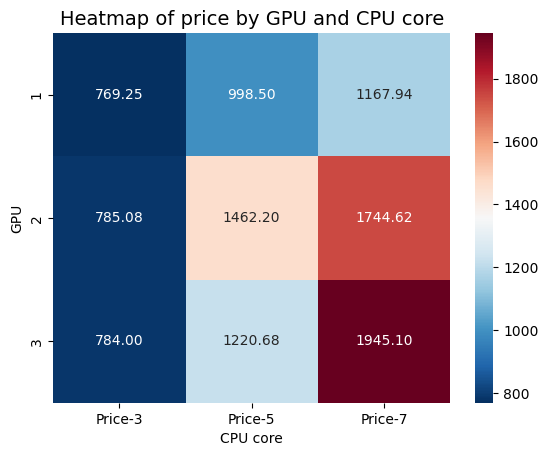

In [18]:
sns.heatmap(pivot_GPU_CPU_core, 
            cmap = "RdBu_r", 
            annot = True,
           fmt= ".2f")
plt.title("Heatmap of price by GPU and CPU core", fontsize = 14)
plt.xlabel("CPU core")
plt.ylabel("GPU")
plt.show()

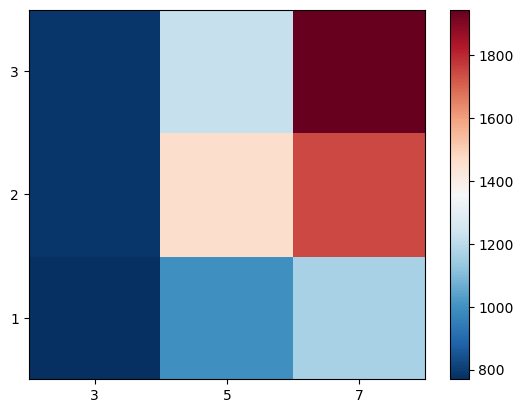

In [19]:
fig, ax = plt.subplots()
im = ax.pcolor(pivot_GPU_CPU_core, cmap = "RdBu_r")

xlabels = pivot_GPU_CPU_core.columns.levels[1]
ylabels = pivot_GPU_CPU_core.index

ax.set_xticks(np.arange(pivot_GPU_CPU_core.shape[1]) +0.5, minor = False)
ax.set_yticks(np.arange(pivot_GPU_CPU_core.shape[0])+0.5, minor = False)

ax.set_xticklabels(xlabels)
ax.set_yticklabels(ylabels)

fig.colorbar(im)


<h3>Pearson Correlations:</h3>

In [20]:
import jinja2

categories = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]
iv = "Price"
results=[]
for cat in categories:
    pearson_coef, p_value = stats.pearsonr(df[cat], df[iv])
    
    sig = "Sig" if p_value <= .05 else "ns"
    
    if p_value < .0001:
        p_value_print = "<.0001"
    else:
        p_value_print = f"{p_value:.3f}"

    results.append({
        "Association":f" {cat} Vs {iv}",
        "r":f"{pearson_coef:.2f}",
        "<i>p</i>-value": f"{p_value_print} {sig}"
    })
results_2 = pd.DataFrame(results)

styled = (
    results_2.style
    .hide(axis = "index")
    .set_properties(subset=["Association"], **{"text-align": "left"})
    .set_properties(subset=["r", "<i>p</i>-value"], **{"text-align": "right"})
)

display(HTML(styled.to_html(escape = False)))

Association,r,p-value
Category Vs Price,0.29,<.0001 Sig
GPU Vs Price,0.29,<.0001 Sig
OS Vs Price,-0.22,0.001 Sig
CPU_core Vs Price,0.46,<.0001 Sig
RAM_GB Vs Price,0.55,<.0001 Sig
Storage_GB_SSD Vs Price,0.24,0.000 Sig


In [21]:
styled.to_html("correlation_table.html")

In [22]:
styled.to_excel("correlation_table.xlsx", engine = "openpyxl")